# Feature Engineering

#### Import Libraries

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\projects\tenx\projects\credit-risk-model


In [2]:
from src.data_processing import (
    build_feature_pipeline,
    calculate_rfm,
    create_proxy_target, 
)
from src.data_loader import load_data
from src.preprocessing import (
    get_categorical_cols,
    get_numerical_cols,
)


2026-06-12 13:24:41,973 [INFO] Embedded WoE/IV utilities into data_processing module


In [3]:
df = load_data("../data/processed/processed_data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


### **Feature Engineering**

In [4]:
CATEGORICAL_COLS = get_categorical_cols(df)
NUMERICAL_COLS = get_numerical_cols(df)

In [5]:
df.dtypes

TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                       category
CountryCode                        category
ProviderId                         category
ProductId                          category
ProductCategory                    category
ChannelId                          category
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                    category
FraudResult                            bool
dtype: object

In [6]:
pipeline = build_feature_pipeline(
    categorical_cols=CATEGORICAL_COLS,
    numerical_cols=NUMERICAL_COLS,
    scaling_method="standard"
)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('missing_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,numerical_strategy,'median'
,categorical_strategy,'most_frequent'
,numerical_cols,"['Amount', 'Value']"
,iqr_multiplier,1.5
,target_col,'is_high_risk'
,categorical_cols,"['CurrencyCode', 'CountryCode', ...]"
,categorical_cols,"['CurrencyCode', 'CountryCode', ...]"


### **RFM Metrics**

In [7]:
rfm = calculate_rfm(df, snapshot_date=None)  # or '2023-12-31'
rfm.head()

,CustomerId,Recency,Frequency,Monetary,AvgMonetary,FirstTransaction,LastTransaction
0,CustomerId_1,2759,1,-10000.0,-10000.000000,2018-11-21 16:49:14,2018-11-21 16:49:14
1,CustomerId_10,2759,1,-10000.0,-10000.000000,2018-11-21 16:49:09,2018-11-21 16:49:09
2,CustomerId_1001,2765,5,20000.0,4000.000000,2018-11-16 07:53:19,2018-11-16 08:20:39
3,CustomerId_1002,2702,11,4225.0,384.090909,2018-11-15 18:50:09,2019-01-18 10:05:00
4,CustomerId_1003,2687,6,20000.0,3333.333333,2019-02-01 14:58:07,2019-02-01 15:04:51


### **High-Risk**

2026-06-12 13:24:44,868 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\teMelkishi\Desktop\projects\tenx\projects\credit-risk-model\src\data_processing.py:584: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
2026-06-12 13:24:44,877 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Cluster Summary (for high-risk identification):
         Recency  Frequency      Monetary  CustomerId
Cluster                                              
0        2736.88       7.72  8.166411e+04        1427
1        2687.74      34.81  2.726914e+05        2314
2        2704.00    4091.00 -1.049000e+08           1


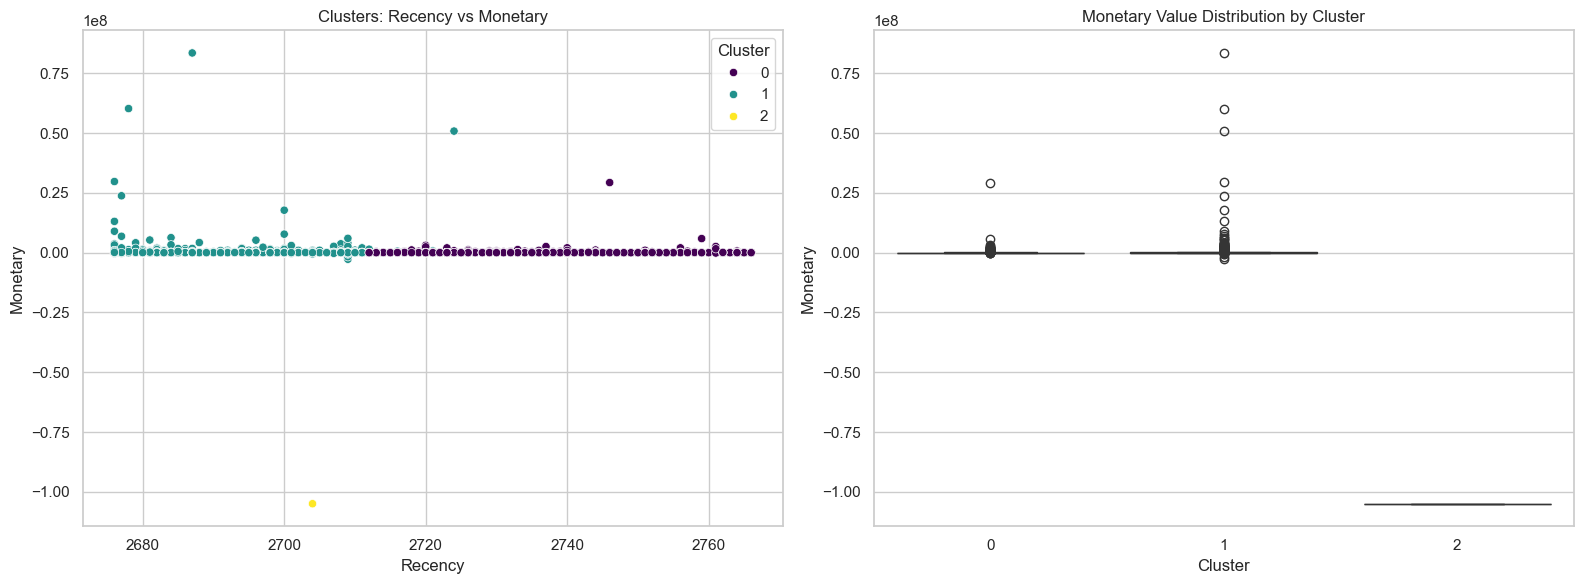

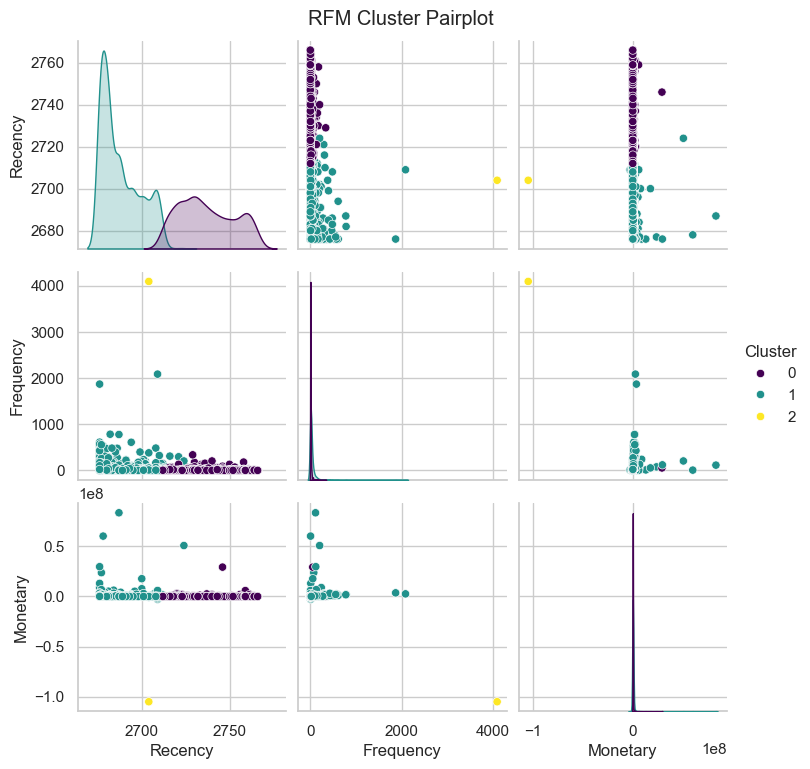

High-risk cluster identified: 0
Proxy target created: is_high_risk
0    0.885
1    0.115
Name: proportion, dtype: float64
High-risk customers: 11,010 out of 95,662


In [8]:
df_with_target = create_proxy_target(df, snapshot_date=None)   # or '2023-12-31'

In [9]:
X_transformed = pipeline.fit_transform(df_with_target)
y = df_with_target['is_high_risk']

print("Final shape:", X_transformed.shape)
print("Target distribution:", y.value_counts(normalize=True))

Final shape: (95662, 80)
Target distribution: is_high_risk
0    0.884907
1    0.115093
Name: proportion, dtype: float64
